In [28]:
# Imports and loading of NEURON dll
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import bz2
import pickle
import _pickle as cPickle

In [29]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def sigmoid(xs,m,b):
    '''Functional form of a sigmoid.
    PARAMETERS:
        xs: x values to evaluate (array or scalar).
        m: slope of curve.
        b: intercept of the curve.
    RETURNS:
        A probability evaluated at each xs (either array or scalar).
    RAISES:
        None.
    '''
    return 1/ (1 + np.exp(-m*(xs - b)))
    
def fitsigmoid(stim_amps,spike_probs):
    '''Function to fit a sigmoidal curve using nonlinear least squares
    (scipy.optimize.curve_fit) to an activation curve from a single electrode 
    scan experiment.
    PARAMETERS:
        stim_amps: array of stimulation amplitudes provided during a single 
            electrode scan.
        spike_probs: array of probababilties in response to each delivered 
            amplitude.
    RETURNS:
        sigmoid_fit: a sigmoid fitted to the activation curve using non-linear 
            least squares.
        popt: the optimal parameters from fitting procedure.
    RAISES:
        ValueError: 
            If the stim_amps and spike_probs are different sizes.
    '''
    # Check input sizes.
    if np.shape(stim_amps) != np.shape(spike_probs):
        raise ValueError("Amplitude and probability arrays must have the"\
                         " same dimensions.")
        
    # Fit the curve to the data.
    popt,pcov = curve_fit(sigmoid,stim_amps,spike_probs,maxfev=10000000,p0=[0,0])
    # sigmoid_fit = sigmoid(stim_amps,*popt)
    return popt

## Plotting somatic sigmoid v2

In [47]:
# load in spike probability data pickle files 
spike_probs = []

# # -------- test electrode ---------
# electrode = [-100, 0, 50]
electrode = [60, -90, 45]

# currents = np.linspace(0, 2, 100)
# current_range = []

currents = np.linspace(0, 2.5, 100)
current_range = []


for current in currents: 
    if current < 3:
        current_range.append(current)
        filename = '/Volumes/Scratch/Users/vilkhu/sim-data/sigmoid/fixed/somatic_real/knoise_00060/'+\
                    str(current)+'uA'+'.pkl'
        
        
        data = decompress_pickle(filename)

        spike_probs.append(data[0])

(0.0, 2.5)

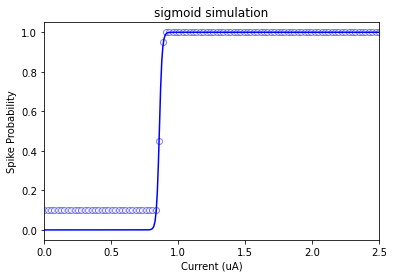

In [48]:
# Plot the sigmoid curve
spike_probs = np.asarray(spike_probs)

# fit sigmoids
popt_somatic = fitsigmoid(current_range,spike_probs)

# upsamples x-axis
x = np.linspace(0, 2.5, 300)

fig = plt.figure()
ax = fig.add_subplot(111)

# make the facecolor = None
ax.scatter(current_range, spike_probs, facecolor='white', edgecolor='blue', alpha=0.5)
ax.plot(x, sigmoid(x, *popt_somatic), color='blue', label='somatic')


ax.set_ylabel('Spike Probability')
ax.set_xlabel('Current (uA)')
ax.set_title('sigmoid simulation')
ax.set_xlim([0,2.5])
# ax.set_ylim([-0.05,1.05])
# plt.savefig("figure2_sigmoid_soma.pdf",format="pdf", bbox_inches="tight")


## Ploting axonal sigmoid v2

In [32]:
# load in spike probability data pickle files 
spike_probs = []

# # -------- test electrode ---------
# electrode = [-1000, 0, 50]
electrode = [-30, -375, 42]

# currents = np.linspace(0, 3, 100)
currents = np.linspace(0, 2.5, 100)
current_range = []


for current in currents: 
    if current < 2.5:
        current_range.append(current)
        filename = '/Volumes/Scratch/Users/vilkhu/sim-data/sigmoid/fixed/axonal_real/knoise_00060/'+\
                    str(current)+'uA'+'.pkl'
        # filename = '/Volumes/Scratch/Users/vilkhu/sim-data/sigmoid/fixed/dendritic_real/knoise_00030/'+\
        #             str(current)+'uA'+'.pkl'
        
        data = decompress_pickle(filename)

        spike_probs.append(data[0])

<function matplotlib.pyplot.show(close=None, block=None)>

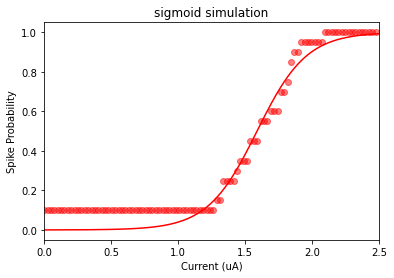

In [33]:
# Plot the sigmoid curve
spike_probs = np.asarray(spike_probs)

# fit sigmoids
popt_axonal = fitsigmoid(current_range,spike_probs)

# upsamples x-axis
x = np.linspace(0, 2.5, 300)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(current_range, spike_probs, color='red', alpha=0.5)
ax.plot(x, sigmoid(x, *popt_axonal), color='red', label='axonal')


ax.set_ylabel('Spike Probability')
ax.set_xlabel('Current (uA)')
ax.set_title('sigmoid simulation')
ax.set_xlim([0,2.5])
# plt.savefig("figure2_sigmoid_dend.pdf",format="pdf", bbox_inches="tight")
plt.show

## Plot triphasic results

In [32]:
# load in S-D data pickle files 
electrodes = []
# -------- test electrodes ---------
for x in range(31):
    electrodes.append([-100, 0, 47+(x*0.5)])

thresholds = []

for elec in electrodes: 
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/ERF/triphasic/15um/0.05ms/anodic_'+\
                str(elec[0])+'_'+\
                str(elec[1])+'_'+str(elec[2])+'_erf.pkl'
    
    data = decompress_pickle(filename)

    thresholds.append(data[0])

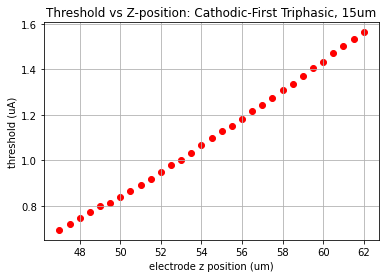

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

for i,elec in enumerate(electrodes):
    ax.scatter(elec[2], thresholds[i]*(2/3), c='r')

ax.set_ylabel('threshold (uA)')
ax.set_xlabel('electrode z position (um)')
ax.set_title('Threshold vs Z-position: Cathodic-First Triphasic, 15um')
ax.grid()

## Plot pillar electrode sigmoids

In [3]:
# load in spike probability data pickle files 
spike_probs = []

# # -------- test electrode ---------
electrodes = [[-5,0,57],[-65,0,57]]

# -------- test currents ----------
currents = np.linspace(0, 4, 30)


for electrode in electrodes:
    spike_probs_temp = []
    for current in currents: 
        filename = '/Volumes/Scratch/Users/vilkhu/sim-data/sigmoid/pillars/knoise2.5/'+\
                    str(electrode[0])+'_'+\
                    str(electrode[1])+'_'+\
                    str(electrode[2])+'_'+\
                    str(current)+'uA'+'.pkl'
        
        data = decompress_pickle(filename)

        spike_probs_temp.append(data[0])
    spike_probs.append(spike_probs_temp)

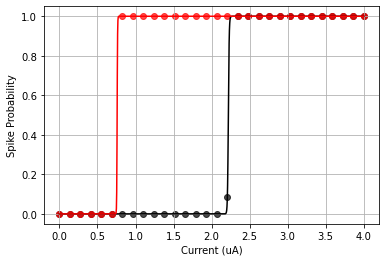

In [5]:
# Plot the sigmoid curve
spike_probs_1 = np.asarray(spike_probs[0])
spike_probs_2 = np.asarray(spike_probs[1])

# fit sigmoids
popt_1 = fitsigmoid(currents,spike_probs_1)
popt_2 = fitsigmoid(currents,spike_probs_2)

# upsamples x-axis
x = np.linspace(0, 4, 1000)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(currents, spike_probs_1, color='black', alpha=0.7)
ax.plot(x, sigmoid(x, *popt_1), color='black')

ax.scatter(currents, spike_probs_2, color='red', alpha=0.7)
ax.plot(x, sigmoid(x, *popt_2), color='red')

ax.set_ylabel('Spike Probability')
ax.set_xlabel('Current (uA)')
ax.grid()

## Load real sigmoid data for paper

In [49]:
# Load the .mat file
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

data = loadmat("/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/2020-10-06-7-data001-sigmoids_and_raw.mat")

In [50]:
data

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Sat Jul 13 05:12:29 2024',
 '__version__': '1.0',
 '__globals__': [],
 'cells': array([[ 78,  81,  84, 171, 220, 242, 244, 259, 275, 282, 283, 292, 296,
         301, 302, 311, 351, 395, 399, 419, 426, 439, 442, 444, 447, 458,
         487, 490, 504, 507, 509, 535, 608, 621, 623, 626]]),
 'all_sigmoids': array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
     

In [51]:
# Determine the index of '535' in an array returned by data['cells']
cell_index = np.where(data['cells'][0] == 535)[0][0]
print(cell_index)
print(data['cells'][0][cell_index])

31
535


In [52]:
# elec = 482 # Somatic
# elec = 444 # Axonal 
# elec = 452 # Axonal **
# elec = 481 # Somatic **
elec = 444 # AXON
# elec = 480 # SOCB
# elec = 107 # DENDRITE
# elec = 90 # DENDRITE
probs = data['all_sigmoids'][cell_index][elec]
print(probs)

[8.21407023e-04 8.94187174e-04 9.32958718e-04 1.01561278e-03
 1.10558134e-03 1.25567693e-03 1.36688260e-03 1.55239775e-03
 1.76304693e-03 2.08893707e-03 2.37221779e-03 2.72227914e-03
 3.22798770e-03 4.53732628e-03 5.37839157e-03 7.55336868e-03
 8.94847957e-03 1.25489557e-02 1.75724191e-02 2.45568118e-02
 4.03408907e-02 5.58603622e-02 8.99104432e-02 1.41603066e-01
 2.46298543e-01 4.21486327e-01 5.89553650e-01 7.39026680e-01
 8.48091632e-01 9.55946699e-01 9.77159112e-01 9.94022087e-01
 9.98455144e-01 9.99602083e-01 9.99897594e-01 9.99986635e-01
 9.99998256e-01 9.99999772e-01 9.99999970e-01 9.99999998e-01]


In [53]:
amps = data['amplitudes'][0]
print(amps)

[-0.10053543 -0.11310236 -0.11938583 -0.13195276 -0.14451969 -0.16337008
 -0.17593701 -0.1947874  -0.2136378  -0.23877165 -0.25762205 -0.2780315
 -0.30330709 -0.35385827 -0.37913386 -0.42968504 -0.45496063 -0.50551181
 -0.55606299 -0.60661417 -0.68244094 -0.73299213 -0.8088189  -0.88464567
 -0.98574803 -1.10433071 -1.20472441 -1.30511811 -1.40551181 -1.60629921
 -1.70669291 -1.90748031 -2.10826772 -2.30905512 -2.50984252 -2.81102362
 -3.11220472 -3.41338583 -3.71456693 -4.1161    ]


In [54]:
raw_amps = data['raw_amps_clean'][cell_index][elec]
raw_amps = np.asarray(-1*raw_amps)
print(raw_amps)
raw_probs = data['raw_probs_clean'][cell_index][elec]
print(raw_probs)

[[0.10053543 0.11310236 0.11938583 0.13195276 0.14451969 0.16337008
  0.17593701 0.1947874  0.2136378  0.23877165 0.25762205 0.2780315
  0.30330709 0.35385827 0.37913386 0.42968504 0.45496063 0.50551181
  0.55606299 0.60661417 0.68244094 0.73299213 0.8088189  0.88464567
  0.98574803 1.10433071 1.20472441 1.60629921 2.50984252]]
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.04 0.04 0.   0.04 0.04 0.   0.   0.08 0.08 0.   0.04 0.48 0.88 0.96
  0.96]]


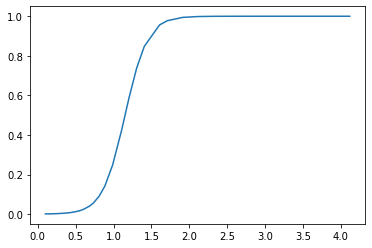

In [55]:
plt.plot(-1*amps,probs)

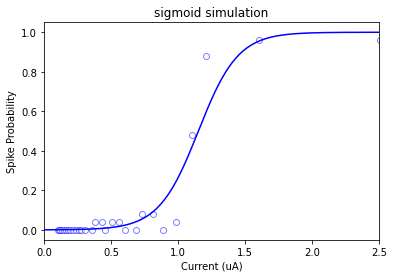

In [56]:
# Plot the sigmoid curve
spike_probs = np.asarray(probs)
current_range = np.asarray(-1*amps)

# fit sigmoids
popt_somatic = fitsigmoid(current_range,spike_probs)

# upsamples x-axis
x = np.linspace(0, 2.5, 300)

fig = plt.figure()
ax = fig.add_subplot(111)

# make the facecolor = None
# ax.scatter(current_range, spike_probs, facecolor='white', edgecolor='blue', alpha=0.5)
ax.scatter(raw_amps, raw_probs, facecolor='white', edgecolor='blue', alpha=0.5)
ax.plot(x, sigmoid(x, *popt_somatic), color='blue', label='somatic')


ax.set_ylabel('Spike Probability')
ax.set_xlabel('Current (uA)')
ax.set_title('sigmoid simulation')
ax.set_xlim([0,2.5])
ax.set_ylim([-0.05,1.05])
plt.savefig("figure2_sigmoid_real_axon.pdf",format="pdf", bbox_inches="tight")

array([1.0], dtype=object)